# Phase 1 — Exploratory Data Analysis (HCC1806)

**Cell line:** HCC1806 (triple-negative breast cancer)  
**Technologies:** Smart-seq (deep, few cells) and Drop-seq (shallow, many cells)  
**Biology:** hypoxia (low oxygen) vs normoxia (normal oxygen), 24h exposure

**Goal:** understand the structure and pitfalls of the data, justify preprocessing choices, see whether the two conditions differ at a coarse level, and compare what the two sequencing technologies look like on the same biology.

**Note on layout:** data files are *genes × cells*. Summing along `axis=0` gives a per-cell total (library size); summing along `axis=1` gives a per-gene total.

In [1]:
import re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

# ---- Edit these paths to match your folder ----
SS_DIR = Path('/Users/nicolasrazzotti/Downloads/AI LAB/SmartSeq')
DS_DIR = Path('/Users/nicolasrazzotti/Downloads/AI LAB/DropSeq')

FILES = {
    'SS_unfiltered': SS_DIR / 'HCC1806_SmartS_Unfiltered_Data.txt',
    'SS_filtered':   SS_DIR / 'HCC1806_SmartS_Filtered_Data.txt',
    'SS_normalised': SS_DIR / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt',
    'SS_meta':       SS_DIR / 'HCC1806_SmartS_MetaData.tsv',
    'DS_normalised': DS_DIR / 'HCC1806_Filtered_Normalised_3000_Data_train.txt',
}

OUTDIR = Path('phase1_outputs')
OUTDIR.mkdir(exist_ok=True)

PALETTE = {'Hypoxia': '#d62728', 'Normoxia': '#1f77b4'}
print('Plots saved to:', OUTDIR.resolve())

Plots saved to: /Users/nicolasrazzotti/Downloads/AI LAB/phase1_outputs


In [2]:
# Helper functions used throughout
def load(path):
    df = pd.read_csv(path, sep=r'\s+', index_col=0, engine='python')
    df.columns = df.columns.str.replace('"', '').str.strip()
    df.index = df.index.astype(str).str.replace('"', '').str.strip()
    return df

def condition_of(name):
    s = name.lower()
    if re.search(r'hypo', s): return 'Hypoxia'
    if re.search(r'norm', s): return 'Normoxia'
    return 'Unknown'

def conditions(df):
    return np.array([condition_of(c) for c in df.columns])

---
# Part A — Smart-seq HCC1806

## 1. Load and describe structure

In [3]:
ss_raw = load(FILES['SS_unfiltered'])
ss_meta = pd.read_csv(FILES['SS_meta'], sep='\t')

print(f'Shape (genes × cells): {ss_raw.shape}')
print(f'Data type: {ss_raw.dtypes.unique()}')
print(f'Missing values: {ss_raw.isna().sum().sum()}')
print(f'Conditions: {pd.Series(conditions(ss_raw)).value_counts().to_dict()}')
print(f'\nFirst 3 cell names:')
for c in ss_raw.columns[:3]:
    print(f'  {c}')
print(f'\nFirst 5 gene names: {list(ss_raw.index[:5])}')
print(f'\nMetadata columns: {list(ss_meta.columns)}')
print(ss_meta.head(2))

Shape (genes × cells): (23396, 243)
Data type: [dtype('int64')]
Missing values: 0
Conditions: {'Hypoxia': 126, 'Normoxia': 117}

First 3 cell names:
  output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam
  output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam
  output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam

First 5 gene names: ['WASH7P', 'CICP27', 'DDX11L17', 'WASH9P', 'OR4F29']

Metadata columns: ['Filename', 'Cell Line', 'PCR Plate', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']
                                            Filename Cell Line  PCR Plate  \
0  output.STAR.PCRPlate1A10_Normoxia_S123_Aligned...   HCC1806          1   
1  output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....   HCC1806          1   

   Pos Condition  Hours Cell name               PreprocessingTag  \
0  A10     Normo     24      S123  Aligned.sortedByCoord.out.bam   
1  A12     Normo     24       S26  Aligned.sortedByCoord.o

**Observations:**
- Integer counts, no NaN values. In RNA-seq a zero count means "gene not detected" — biologically meaningful, not missing data.
- Cell names encode plate, well, condition, and sample (e.g. `output.STAR.PCRPlate1A10_Normoxia_S123...`), so the condition label can be parsed directly from the column name.
- The metadata file gives plate/well/condition annotations, useful later for checking batch effects.

## 2. Per-cell summary statistics

       library_size  mean_expr  genes_detected  zero_fraction
count         243.0     243.00          243.00         243.00
mean      2012306.3      86.01        10330.36           0.56
std       1171858.0      50.09         2260.26           0.10
min           114.0       0.00           35.00           0.40
25%        991062.5      42.36        10117.00           0.51
50%       2067645.0      88.38        10831.00           0.54
75%       2925181.5     125.03        11409.00           0.57
max       5758132.0     246.12        13986.00           1.00


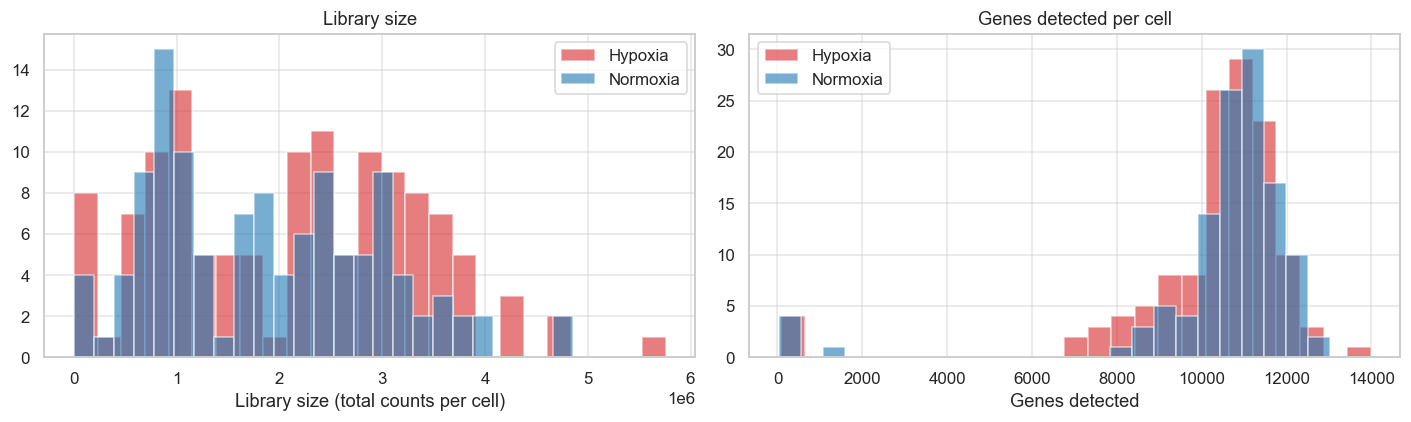

In [4]:
def cell_stats(df):
    return pd.DataFrame({
        'library_size':   df.sum(axis=0),
        'mean_expr':      df.mean(axis=0),
        'genes_detected': (df > 0).sum(axis=0),
        'zero_fraction':  (df == 0).mean(axis=0),
        'Condition':      conditions(df),
    })

cs = cell_stats(ss_raw)
print(cs[['library_size', 'mean_expr', 'genes_detected', 'zero_fraction']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cond, grp in cs.groupby('Condition'):
    axes[0].hist(grp['library_size'], bins=25, alpha=0.6, label=cond, color=PALETTE[cond])
    axes[1].hist(grp['genes_detected'], bins=25, alpha=0.6, label=cond, color=PALETTE[cond])
axes[0].set_xlabel('Library size (total counts per cell)'); axes[0].set_title('Library size'); axes[0].legend()
axes[1].set_xlabel('Genes detected'); axes[1].set_title('Genes detected per cell'); axes[1].legend()
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_01_qc_distributions.png', dpi=150); plt.show()

**Notes:**
- Library sizes vary by orders of magnitude across cells — typical Smart-seq behaviour, since each cell is sequenced in its own well and capture efficiency varies. This motivates normalisation.
- Cells with very few genes detected are candidates for QC filtering (dying / empty wells).

## 3. Do conditions differ at a coarse level?

Before we look at individual genes, we ask: do hypoxia and normoxia cells look different in their global expression statistics? If so, the condition signal is already detectable from very simple summaries — a good sign for downstream classification.

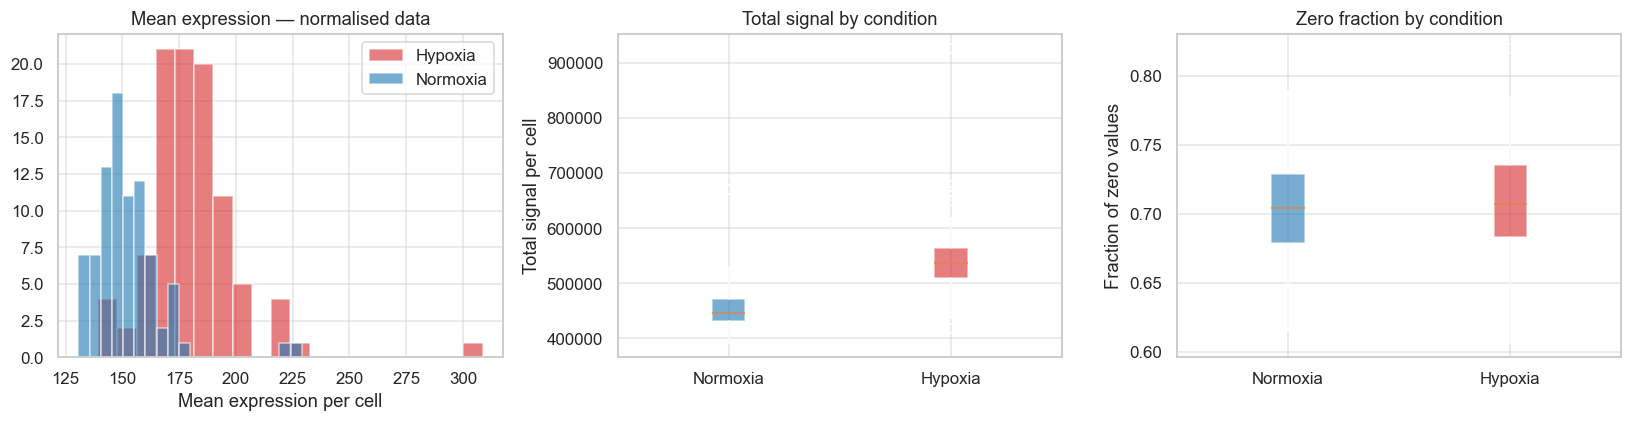


Group medians (normalised data):
           mean_expr  library_size  zero_fraction
Condition                                        
Hypoxia       179.14      537432.0           0.71
Normoxia      148.92      446769.0           0.70


In [5]:
# Use the normalised data here — comparing raw means across conditions would conflate
# biology with sequencing-depth differences. Normalised data removes that confound.
ss_norm = load(FILES['SS_normalised'])
cs_norm = cell_stats(ss_norm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Mean expression per cell (normalised)
for cond, grp in cs_norm.groupby('Condition'):
    axes[0].hist(grp['mean_expr'], bins=20, alpha=0.6, label=cond, color=PALETTE[cond])
axes[0].set_xlabel('Mean expression per cell')
axes[0].set_title('Mean expression — normalised data')
axes[0].legend()

# 2. Total signal (boxplot)
data_total = [cs_norm.loc[cs_norm['Condition']==c, 'library_size'].values for c in ['Normoxia','Hypoxia']]
bp = axes[1].boxplot(data_total, labels=['Normoxia','Hypoxia'], patch_artist=True)
for patch, c in zip(bp['boxes'], [PALETTE['Normoxia'], PALETTE['Hypoxia']]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1].set_ylabel('Total signal per cell')
axes[1].set_title('Total signal by condition')

# 3. Zero fraction by condition
data_zero = [cs_norm.loc[cs_norm['Condition']==c, 'zero_fraction'].values for c in ['Normoxia','Hypoxia']]
bp = axes[2].boxplot(data_zero, labels=['Normoxia','Hypoxia'], patch_artist=True)
for patch, c in zip(bp['boxes'], [PALETTE['Normoxia'], PALETTE['Hypoxia']]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[2].set_ylabel('Fraction of zero values')
axes[2].set_title('Zero fraction by condition')

plt.tight_layout(); plt.savefig(OUTDIR / 'ss_02_condition_comparison.png', dpi=150); plt.show()

# Quick numerical summary
print('\nGroup medians (normalised data):')
print(cs_norm.groupby('Condition')[['mean_expr', 'library_size', 'zero_fraction']].median().round(2))

**What to look for:**
- If the hypoxia distributions are visibly shifted compared to normoxia (in mean expression, total signal, or zero fraction), the condition signal is detectable even at the global level — not just in individual genes. Hypoxia tends to broadly upregulate many genes (the HIF-1α response activates dozens of pathways simultaneously), so it's common to see higher mean expression and lower zero fraction in hypoxia cells.
- If the distributions overlap heavily, the signal is more subtle and we'll need feature-level analysis to find it (which we'll do in Phase 2).

## 4. Raw distributions and the failure of IQR outlier removal

Back to the raw (unfiltered) data: plot raw expression per cell (first 50 cells), then try the standard IQR outlier rule and observe what happens.

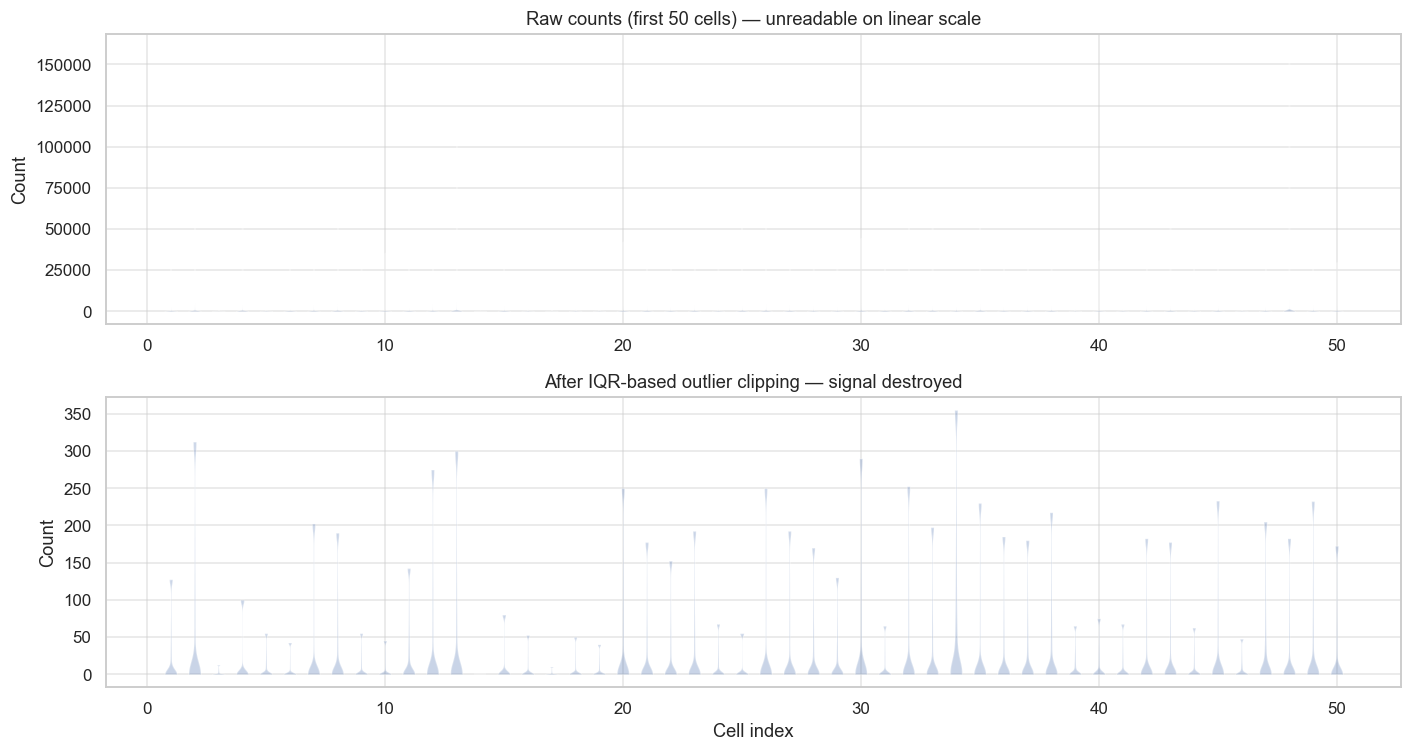

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].violinplot(ss_raw.iloc[:, :50].values, showextrema=False)
axes[0].set_title('Raw counts (first 50 cells) — unreadable on linear scale')
axes[0].set_ylabel('Count')

def iqr_clip(df):
    out = df.copy().astype(float)
    for col in out.columns:
        q1, q3 = out[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        out[col] = out[col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return out

ss_clipped = iqr_clip(ss_raw.iloc[:, :50])
axes[1].violinplot(ss_clipped.values, showextrema=False)
axes[1].set_title('After IQR-based outlier clipping — signal destroyed')
axes[1].set_xlabel('Cell index'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_03_iqr_demo.png', dpi=150); plt.show()

**Key teaching point:** the IQR rule flattens the violins to almost zero. This is because in sparse data the median (and often Q3) is 0 → IQR ≈ 0 → all non-zero values are flagged as outliers. But **the non-zero values are exactly where the biological signal lives.** Naive outlier removal designed for approximately normal data is the wrong tool here. The right approach is (a) log-transform to compress dynamic range, and (b) filter at the cell/gene level on QC criteria, not value-level rules.

## 5. Sparsity

Overall zero fraction: 55.8%


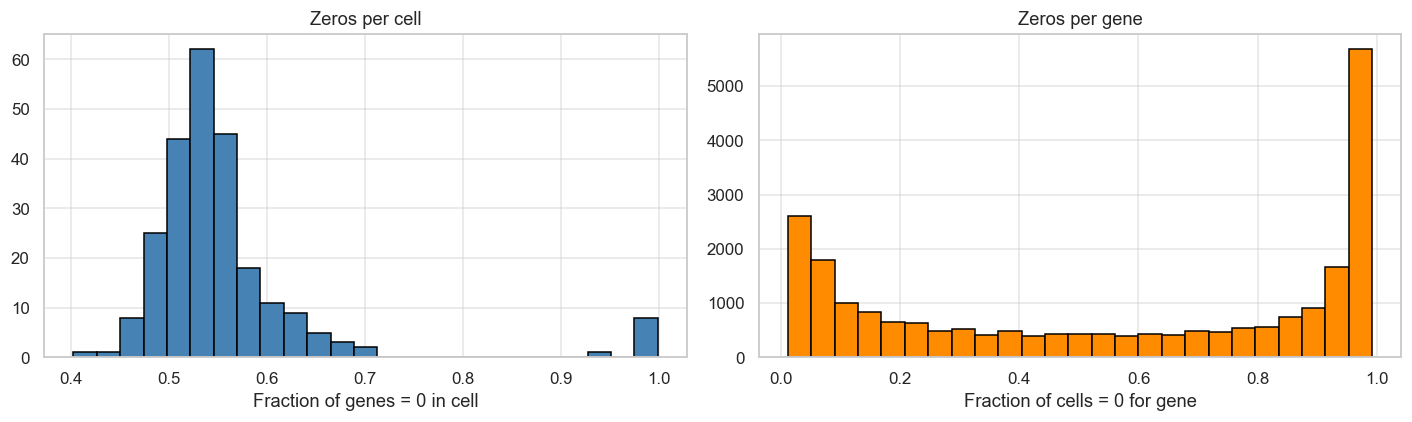

In [7]:
overall = (ss_raw == 0).mean().mean() * 100
print(f'Overall zero fraction: {overall:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist((ss_raw == 0).mean(axis=0), bins=25, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Fraction of genes = 0 in cell'); axes[0].set_title('Zeros per cell')
axes[1].hist((ss_raw == 0).mean(axis=1), bins=25, color='darkorange', edgecolor='black')
axes[1].set_xlabel('Fraction of cells = 0 for gene'); axes[1].set_title('Zeros per gene')
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_04_sparsity.png', dpi=150); plt.show()

**Notes:**
- Around half of all entries are zero — high sparsity, typical of single-cell data.
- The per-gene zero-fraction histogram is **bimodal**: many genes detected in nearly all cells (housekeeping, ribosomal), many in nearly none (tissue-specific genes that don't apply to HCC1806). The latter group will be removed by gene filtering.
- ML implications: sparse-matrix representations save memory; methods robust to zeros (tree-based, log-transformed linear) are preferred.

## 6. Skewness, kurtosis, and the log transform

A normal distribution has skewness 0 and excess kurtosis 0. We compute these per cell on raw data, then on log₂(x+1) transformed data.

Per-cell shape stats (first 50 cells):
      skewness_raw  skewness_log  kurtosis_raw  kurtosis_log
mean         37.79          1.38       2500.50         20.48
50%          32.60          0.80       1612.45         -0.88


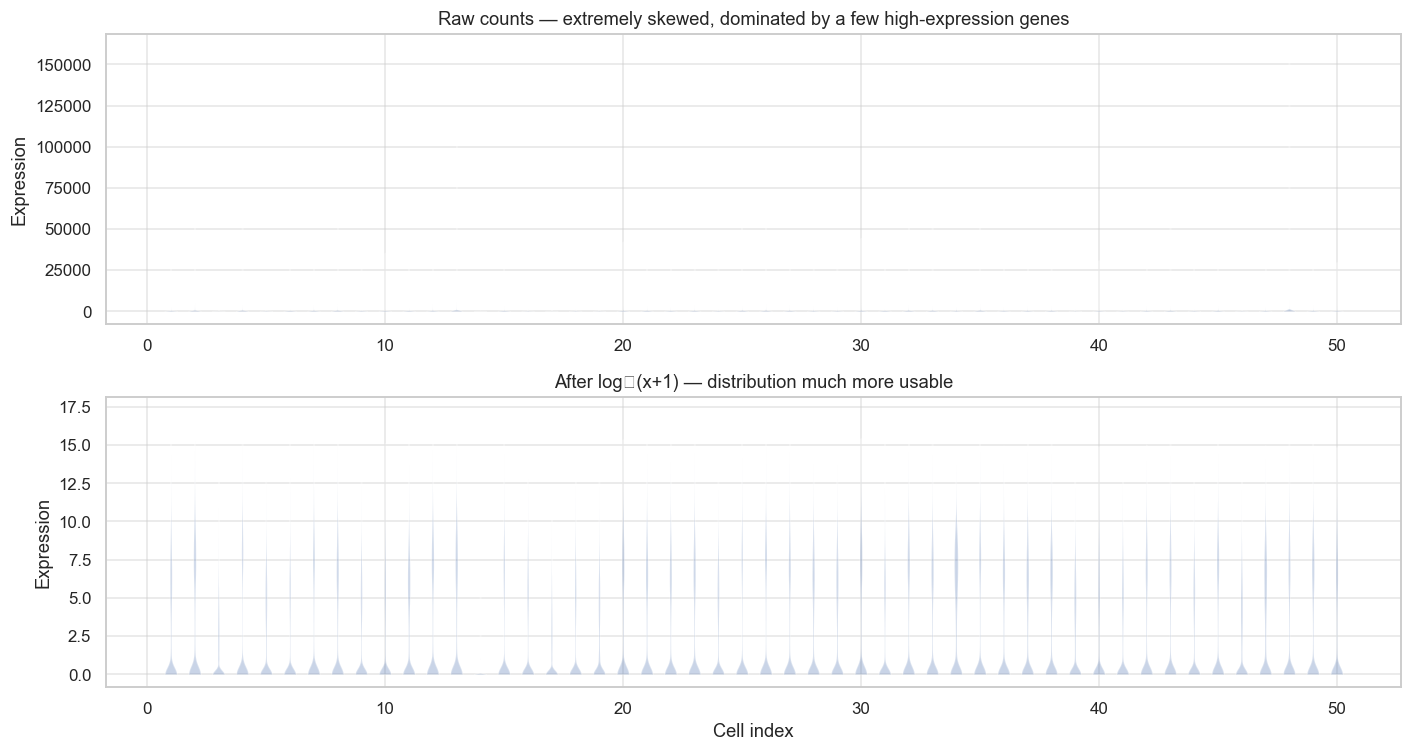

In [8]:
def shape_stats(df, sample=50):
    sub = df.iloc[:, :sample]
    sk = sub.apply(lambda x: skew(x), axis=0)
    ku = sub.apply(lambda x: kurtosis(x), axis=0)
    return sk, ku

sk_raw, ku_raw = shape_stats(ss_raw)
ss_log = np.log2(ss_raw + 1)
sk_log, ku_log = shape_stats(ss_log)

summary = pd.DataFrame({
    'skewness_raw': sk_raw, 'skewness_log': sk_log,
    'kurtosis_raw': ku_raw, 'kurtosis_log': ku_log,
}).describe().loc[['mean', '50%']].round(2)
print('Per-cell shape stats (first 50 cells):')
print(summary)

# Compare violins before/after log
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].violinplot(ss_raw.iloc[:, :50].values, showextrema=False)
axes[0].set_title('Raw counts — extremely skewed, dominated by a few high-expression genes')
axes[1].violinplot(ss_log.iloc[:, :50].values, showextrema=False)
axes[1].set_title('After log₂(x+1) — distribution much more usable')
axes[1].set_xlabel('Cell index')
for ax in axes: ax.set_ylabel('Expression')
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_05_log_transform.png', dpi=150); plt.show()

**Why log₂(x+1) is the standard scRNA-seq move:**
- Compresses dynamic range (a 10,000-fold range becomes a ~14-unit range).
- Makes upregulation and downregulation symmetric: +1 in log space = doubling, -1 = halving.
- The `+1` pseudocount keeps log(0) defined and maps 0 → 0.
- Skewness typically drops from ~50 to ~1, kurtosis from thousands to near zero. Many downstream methods (PCA, distance-based clustering, linear classifiers) assume approximate normality and become far more reliable.

## 7. Per-cell normalisation

Even after log transformation, cells with different library sizes still have systematically different expression *levels*. **Counts-per-million (CPM)** normalisation rescales each cell to a common total, then we log.

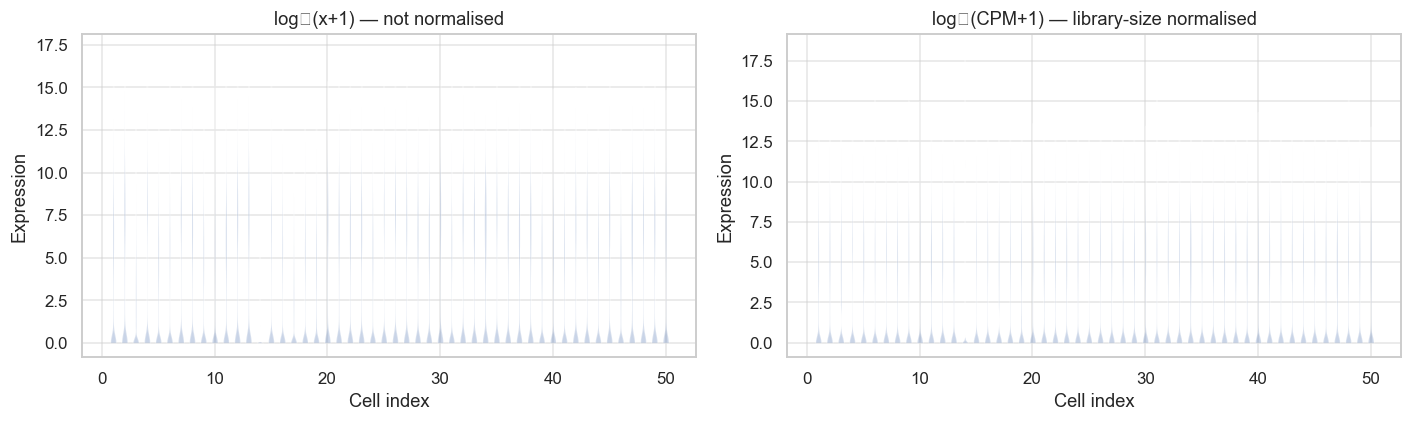

In [9]:
lib = ss_raw.sum(axis=0).replace(0, 1)
ss_logcpm = np.log2(ss_raw.div(lib, axis=1) * 1e6 + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].violinplot(ss_log.iloc[:, :50].values, showextrema=False)
axes[0].set_title('log₂(x+1) — not normalised')
axes[1].violinplot(ss_logcpm.iloc[:, :50].values, showextrema=False)
axes[1].set_title('log₂(CPM+1) — library-size normalised')
for ax in axes: ax.set_xlabel('Cell index'); ax.set_ylabel('Expression')
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_06_normalisation.png', dpi=150); plt.show()

**Reading the plot:** the normalised violins (right) have more comparable medians and spreads across cells. The `_Filtered_Normalised_3000_` files we will use for ML have already been through equivalent processing — we don't need to redo it, just be aware of what was done.

## 8. Gene-level statistics: which genes dominate the data?

Two views: which genes have the highest total expression (these are often housekeeping/ribosomal/mitochondrial — abundant in every cell), and how mean expression relates to variance across genes.

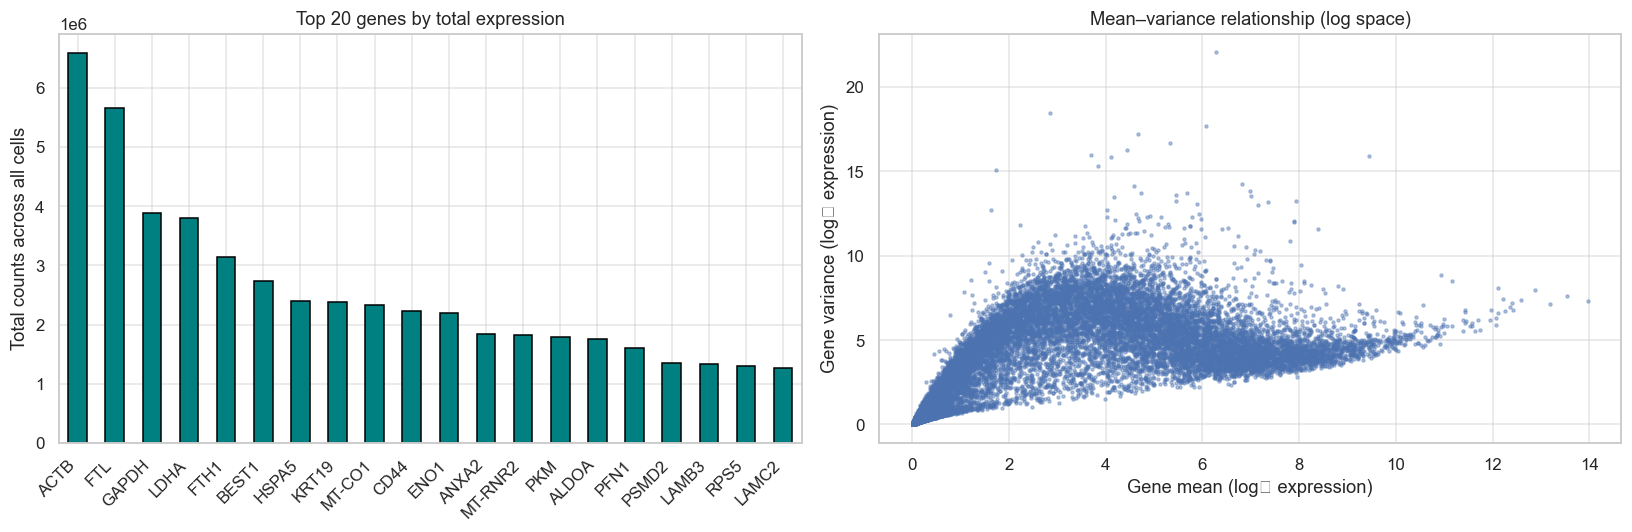

Top 10 genes by total counts (often housekeeping / ribosomal / mitochondrial):
ACTB      6582141
FTL       5663309
GAPDH     3888234
LDHA      3803983
FTH1      3144409
BEST1     2731678
HSPA5     2401217
KRT19     2385035
MT-CO1    2335973
CD44      2221083
dtype: int64


In [10]:
# Top 20 genes by total expression (raw data)
gene_totals = ss_raw.sum(axis=1).sort_values(ascending=False)
top20 = gene_totals.head(20)

# Mean vs variance per gene (on log-transformed data)
gene_mean = ss_log.mean(axis=1)
gene_var  = ss_log.var(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top20.plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Top 20 genes by total expression')
axes[0].set_ylabel('Total counts across all cells')
axes[0].tick_params(axis='x', rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha('right')

axes[1].scatter(gene_mean, gene_var, s=4, alpha=0.4)
axes[1].set_xlabel('Gene mean (log₂ expression)')
axes[1].set_ylabel('Gene variance (log₂ expression)')
axes[1].set_title('Mean–variance relationship (log space)')

plt.tight_layout(); plt.savefig(OUTDIR / 'ss_07_gene_level.png', dpi=150); plt.show()

print('Top 10 genes by total counts (often housekeeping / ribosomal / mitochondrial):')
print(top20.head(10))

**What this tells us:**
- The top-expressed genes are typically housekeeping or structural genes that are abundant in every cell (e.g. `MALAT1`, ribosomal proteins, mitochondrial RNA). These genes have **high mean but low variance** — they don't help discriminate between conditions and are not the ones we want as features for classification.
- The mean–variance scatter shows there's a positive trend (more abundant genes tend to vary more in absolute terms), but the **genes useful for classification** are those that have higher variance *than expected for their mean level* — i.e. above the trend. This is what the top-3000-most-variable-genes selection step targets.

## 9. Duplicate gene names and cell–cell correlation

Duplicate gene names: 0
Fully identical rows: 89


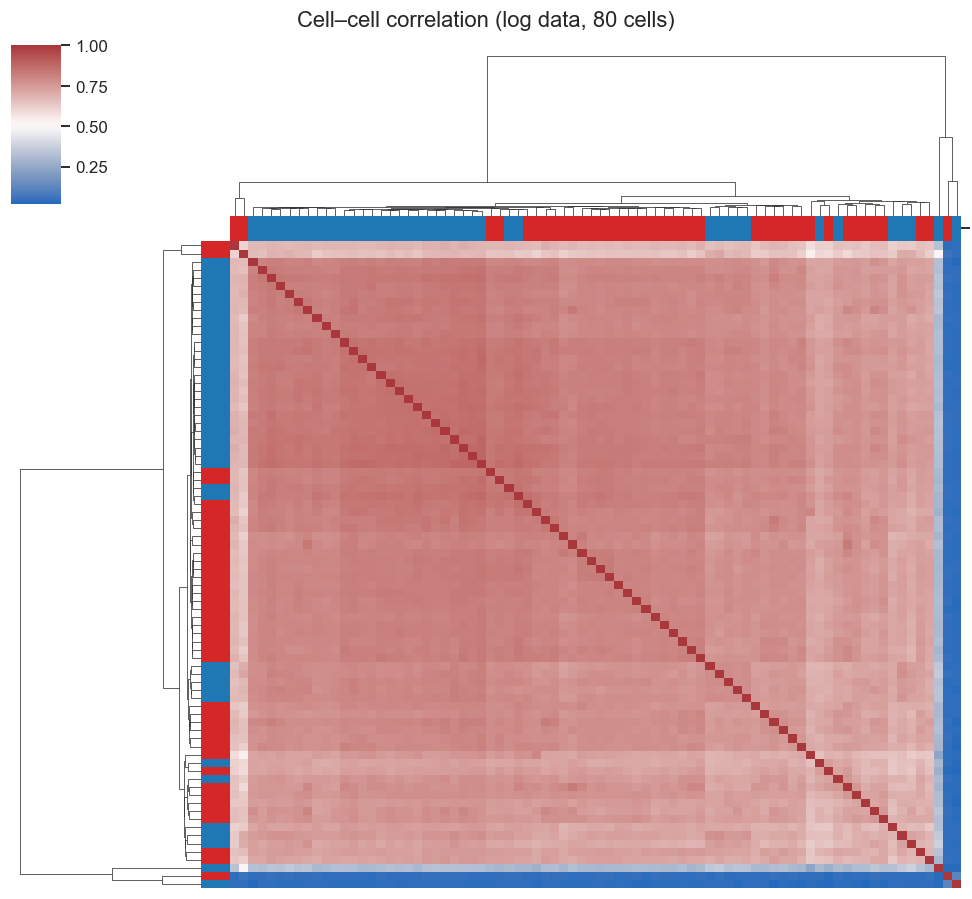


10 lowest-correlation cells:
                                                    library_size  \
output.STAR.PCRPlate3D11_Normoxia_S92_Aligned.s...           164   
output.STAR.PCRPlate3D10_Normoxia_S188_Aligned....           677   
output.STAR.PCRPlate2E12_Normoxia_S61_Aligned.s...           277   
output.STAR.PCRPlate3D3_Hypoxia_S72_Aligned.sor...           342   
output.STAR.PCRPlate3D2_Hypoxia_S168_Aligned.so...           510   
output.STAR.PCRPlate1B1_Hypoxia_S98_Aligned.sor...           447   
output.STAR.PCRPlate3D5_Hypoxia_S78_Aligned.sor...           649   
output.STAR.PCRPlate2F12_Normoxia_S62_Aligned.s...           114   
output.STAR.PCRPlate2G10_Normoxia_S157_Aligned....        479324   
output.STAR.PCRPlate4B1_Hypoxia_S221_Aligned.so...        218240   

                                                    genes_detected  \
output.STAR.PCRPlate3D11_Normoxia_S92_Aligned.s...              35   
output.STAR.PCRPlate3D10_Normoxia_S188_Aligned....              71   
output.STAR

In [11]:
print(f'Duplicate gene names: {ss_raw.index.duplicated().sum()}')
print(f'Fully identical rows: {ss_raw.duplicated(keep=False).sum()}')

# Cell-cell correlation on log data, 80 sampled cells
rng = np.random.default_rng(42)
idx = rng.choice(ss_log.shape[1], 80, replace=False)
sub = ss_log.iloc[:, idx]
cond = pd.Series(conditions(sub), index=sub.columns)
row_colors = cond.map(PALETTE)

g = sns.clustermap(sub.corr(), cmap='vlag', row_colors=row_colors, col_colors=row_colors,
                   figsize=(9, 8), xticklabels=False, yticklabels=False)
g.fig.suptitle('Cell–cell correlation (log data, 80 cells)', y=1.02)
g.savefig(OUTDIR / 'ss_08_cell_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Check: are low-correlation cells the low-quality ones?
corr = ss_log.corr()
np.fill_diagonal(corr.values, np.nan)
mean_corr = corr.mean(axis=1)
cs2 = cell_stats(ss_raw)
cs2['mean_corr'] = mean_corr
print('\n10 lowest-correlation cells:')
print(cs2.sort_values('mean_corr').head(10)[['library_size','genes_detected','zero_fraction','mean_corr']].round(3))

**Observations:**
- Duplicated rows reflect annotation redundancy — same locus listed twice with different identifiers. Standard to drop duplicates before ML.
- Most cells are highly correlated with each other (they share the HCC1806 baseline transcriptome).
- The lowest-correlation cells should also have low library size and high zero-fraction — they are technical failures, exactly the cells removed by the filtering step.
- If the heatmap shows a clear block structure matching the condition side-colours, the hypoxia/normoxia signal is strong enough to be visible at the level of global gene expression.

## 10. Top variable genes — visualised on a clustermap

Take the 50 genes with the highest variance in log space, z-score each across cells, and plot a clustermap. If the conditions separate, cells of the same condition cluster together via these genes.

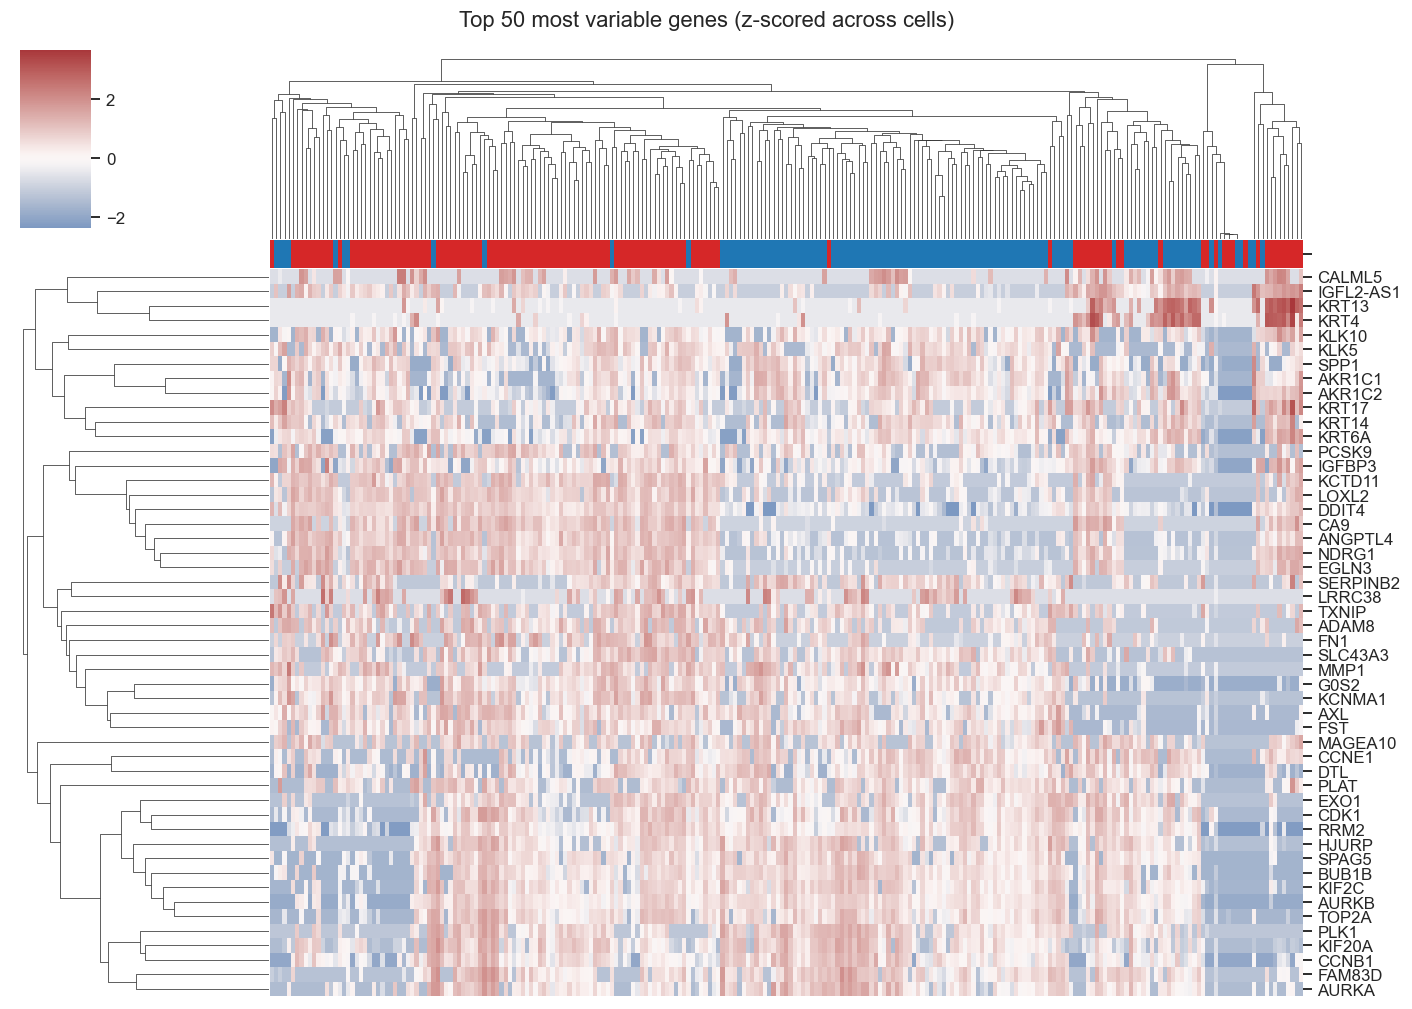

In [12]:
top_var = ss_log.var(axis=1).nlargest(50).index
mat = ss_log.loc[top_var]                # 50 × cells
# Z-score each gene across cells for readability
mat_z = (mat.sub(mat.mean(axis=1), axis=0)).div(mat.std(axis=1), axis=0)

cond_full = pd.Series(conditions(ss_log), index=ss_log.columns)
col_colors = cond_full.map(PALETTE)

g = sns.clustermap(mat_z, cmap='vlag', center=0, col_colors=col_colors,
                   figsize=(13, 9), xticklabels=False, yticklabels=True)
g.fig.suptitle('Top 50 most variable genes (z-scored across cells)', y=1.02)
g.savefig(OUTDIR / 'ss_09_top_variable_genes.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the clustermap:** the top colour bar marks the condition of each column. If hypoxia and normoxia cells separate into distinct blocks along the columns, the top-variable genes are capturing the condition signal. Look for canonical hypoxia genes (`DDIT4, ANGPTL4, NDRG1, EGLN3, CA9, BNIP3`) among the row labels — these should be high in hypoxia columns (red) and low in normoxia columns (blue).

## 11. Compare the three processing stages

The instructor asks to repeat the EDA on the unfiltered, filtered, and normalised versions. Rather than redoing every plot, we summarise the key changes.

          stage  n_genes  n_cells  pct_zeros  median_libsize
     unfiltered    23396      243  55.845623       2067645.0
       filtered    19503      227  45.205606       2157007.0
normalised+3000     3000      182  70.653480        497586.5


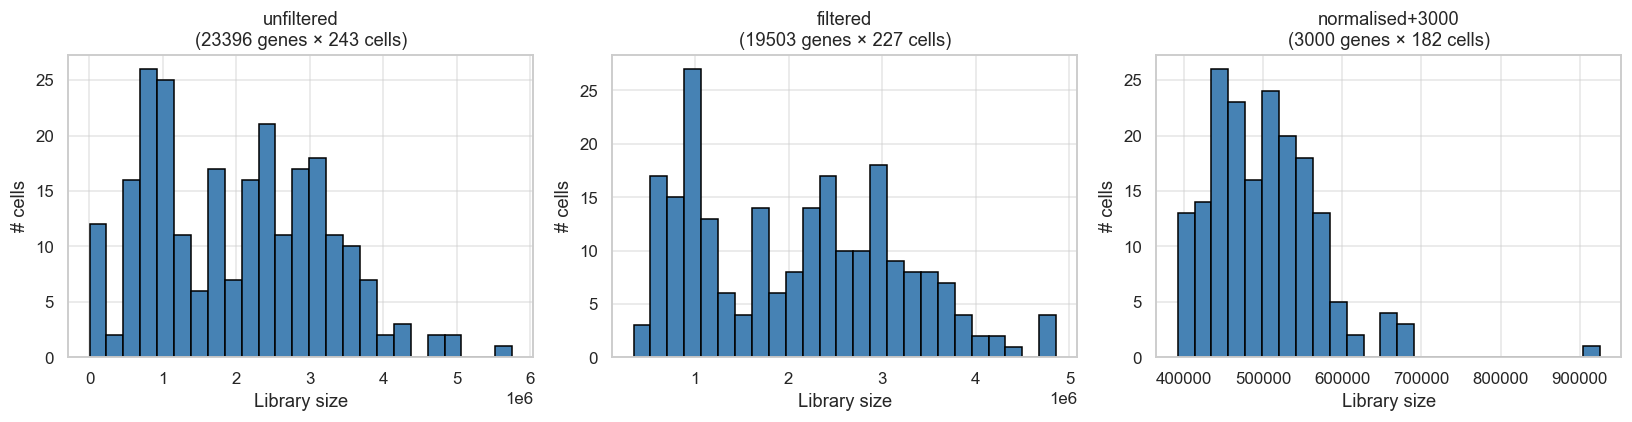

In [13]:
ss_filt = load(FILES['SS_filtered'])

stages = {'unfiltered': ss_raw, 'filtered': ss_filt, 'normalised+3000': ss_norm}

summary = pd.DataFrame([
    {
        'stage': name,
        'n_genes': d.shape[0],
        'n_cells': d.shape[1],
        'pct_zeros': (d == 0).mean().mean() * 100,
        'median_libsize': d.sum(axis=0).median(),
    } for name, d in stages.items()
])
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, stages.items()):
    ax.hist(d.sum(axis=0), bins=25, color='steelblue', edgecolor='black')
    ax.set_title(f'{name}\n({d.shape[0]} genes × {d.shape[1]} cells)')
    ax.set_xlabel('Library size'); ax.set_ylabel('# cells')
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_10_stages.png', dpi=150); plt.show()

**What the three stages do:**
- **Unfiltered → Filtered**: removes low-quality cells (low library size, few genes detected) and low-expression genes. Reduces both dimensions.
- **Filtered → Normalised + top 3000**: library-size normalisation makes cells comparable; selecting the top 3000 most-variable genes drops uninformative low-variance features. This is what we'll use for ML.

---
# Part B — Drop-seq HCC1806

Drop-seq captures many cells at low depth per cell. We have only the normalised+3000 file (no raw/filtered Drop-seq data was provided), so this section is more compact than the Smart-seq one.

In [14]:
ds = load(FILES['DS_normalised'])
print(f'Shape (genes × cells): {ds.shape}')
print(f'Conditions: {pd.Series(conditions(ds)).value_counts().to_dict()}')
print(f'\nFirst 3 cell names:')
for c in ds.columns[:3]:
    print(f'  {c}')
print(f'\nFirst 5 gene names: {list(ds.index[:5])}')
print(f'\nOverall zero fraction: {(ds == 0).mean().mean() * 100:.1f}%')

ds_cs = cell_stats(ds)
print('\nPer-cell stats:')
print(ds_cs[['library_size', 'mean_expr', 'genes_detected', 'zero_fraction']].describe().round(2))

Shape (genes × cells): (3000, 14682)
Conditions: {'Hypoxia': 8899, 'Normoxia': 5783}

First 3 cell names:
  AAAAAACCCGGC_Normoxia
  AAAACCGGATGC_Normoxia
  AAAACGAGCTAG_Normoxia

First 5 gene names: ['H1-5', 'MALAT1', 'MT-RNR2', 'ARVCF', 'BCYRN1']

Overall zero fraction: 97.6%

Per-cell stats:
       library_size  mean_expr  genes_detected  zero_fraction
count      14682.00   14682.00        14682.00       14682.00
mean         106.50       0.04           70.87           0.98
std           26.59       0.01           24.61           0.01
min           39.00       0.01           18.00           0.94
25%           87.00       0.03           51.00           0.97
50%          102.00       0.03           67.00           0.98
75%          124.00       0.04           88.00           0.98
max          220.00       0.07          166.00           0.99


**Drop-seq characteristics to highlight in the report:**
- ~15,000 cells (vs ~250 in Smart-seq) — much greater statistical power for population-level effects.
- Cells identified by random 12-base barcodes plus condition tag (e.g. `AAAAAACCCGGC_Normoxia`).
- **Library size ~100 reads per cell** (Smart-seq was in the hundreds of thousands), **~97% sparsity**. Each cell is a very partial view of the transcriptome.
- Class balance is uneven: more Hypoxia than Normoxia cells (will need stratified CV in Phase 3).

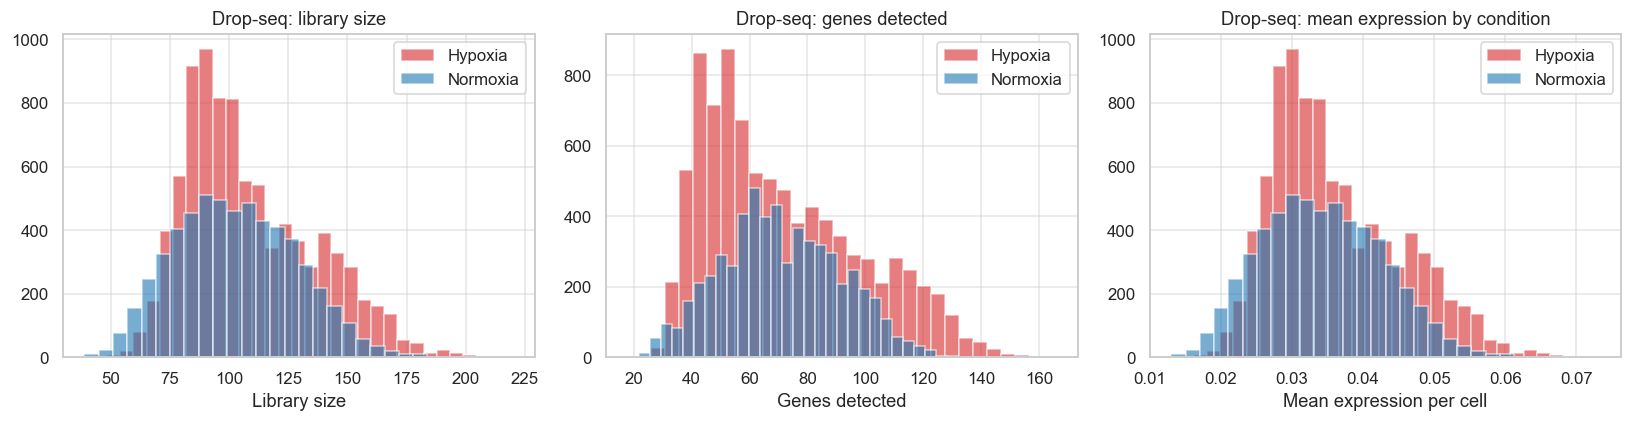

Group medians:
           mean_expr  library_size  genes_detected  zero_fraction
Condition                                                        
Hypoxia        0.034         102.0            65.0          0.978
Normoxia       0.034         102.0            69.0          0.977


In [15]:
# Drop-seq: QC distributions and per-condition comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cond, grp in ds_cs.groupby('Condition'):
    axes[0].hist(grp['library_size'], bins=30, alpha=0.6, label=cond, color=PALETTE[cond])
    axes[1].hist(grp['genes_detected'], bins=30, alpha=0.6, label=cond, color=PALETTE[cond])
axes[0].set_xlabel('Library size'); axes[0].set_title('Drop-seq: library size'); axes[0].legend()
axes[1].set_xlabel('Genes detected'); axes[1].set_title('Drop-seq: genes detected'); axes[1].legend()

# Mean expression per cell by condition
for cond, grp in ds_cs.groupby('Condition'):
    axes[2].hist(grp['mean_expr'], bins=30, alpha=0.6, label=cond, color=PALETTE[cond])
axes[2].set_xlabel('Mean expression per cell')
axes[2].set_title('Drop-seq: mean expression by condition')
axes[2].legend()
plt.tight_layout(); plt.savefig(OUTDIR / 'ds_01_qc_distributions.png', dpi=150); plt.show()

print('Group medians:')
print(ds_cs.groupby('Condition')[['mean_expr', 'library_size', 'genes_detected', 'zero_fraction']].median().round(3))

**Note for Drop-seq:** with 14,682 cells, condition-level shifts in global statistics are more reliably visible (more power than Smart-seq's ~200 cells). Watch for shifts in mean expression / genes detected between Hypoxia and Normoxia — these are again population-level signals of the hypoxia response.

## Top variable genes in Drop-seq

Top 20 genes by total expression (Drop-seq):
H4C3        49418
FTL         45029
RPS5        38340
MALAT1      27886
HSP90AA1    22715
HSP90B1     22274
ENO1        22267
HSP90AB1    20625
RPS28       20396
RPL8        18288
dtype: int64


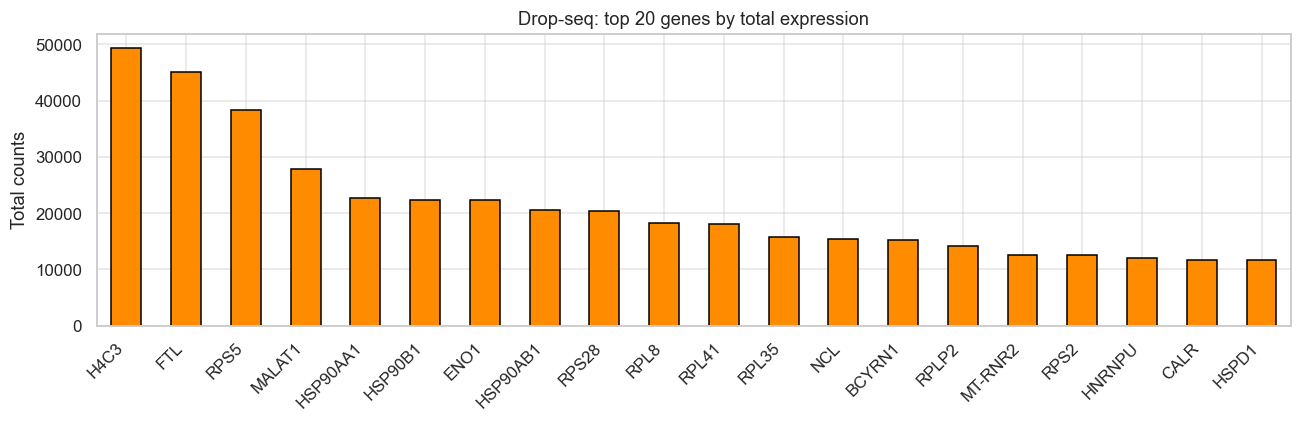

In [16]:
# Top 20 genes by total expression in Drop-seq
ds_log = np.log2(ds + 1)
ds_top20 = ds.sum(axis=1).nlargest(20)
print('Top 20 genes by total expression (Drop-seq):')
print(ds_top20.head(10))

fig, ax = plt.subplots(figsize=(12, 4))
ds_top20.plot(kind='bar', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Drop-seq: top 20 genes by total expression')
ax.set_ylabel('Total counts')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels(): label.set_ha('right')
plt.tight_layout(); plt.savefig(OUTDIR / 'ds_02_top_genes.png', dpi=150); plt.show()

**Note:** the top genes in Drop-seq are typically dominated by `MALAT1`, mitochondrial RNAs (`MT-*`), and ribosomal proteins — these are always abundant and don't help discriminate conditions. The features that matter for classification are not the most expressed ones, but the most *condition-discriminating* ones — that's what we'll find in Phases 2 and 3.

---
# Part C — Side-by-side technology comparison

This is what makes our analysis distinctive: the same biology (HCC1806 hypoxia vs normoxia, 24h) measured by two different technologies.

                         Smart-seq (n=227)  Drop-seq (n=14,682)
Library size (median)          2067645.000              102.000
Genes detected (median)          10831.000               67.000
Zero fraction (median)               0.537                0.978


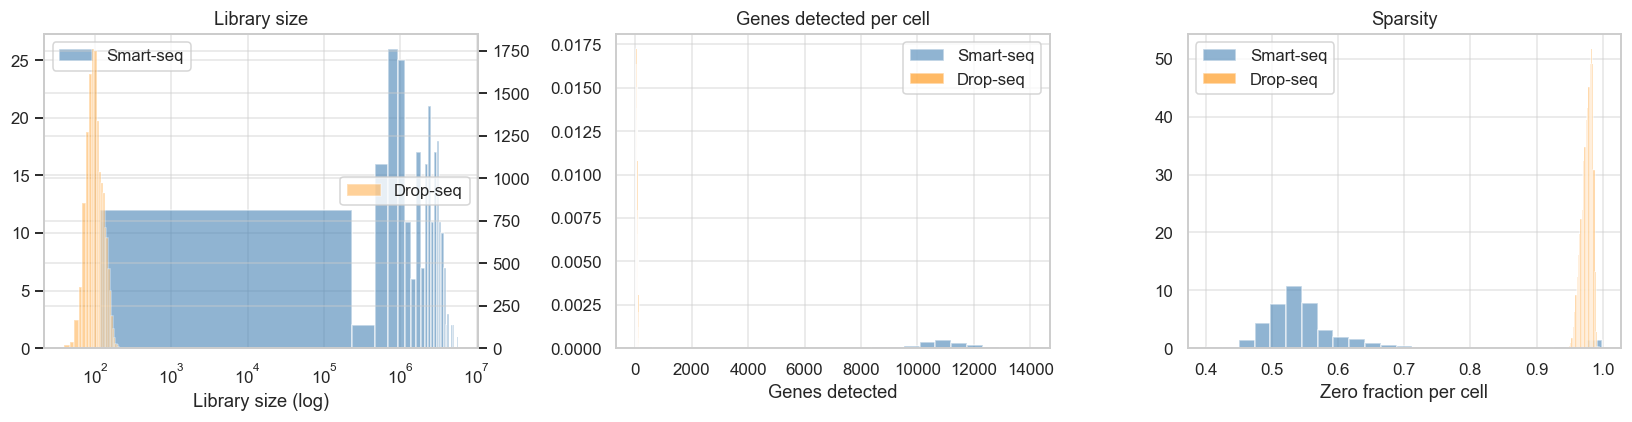

In [17]:
ss_cs = cell_stats(ss_raw)
ds_cs = cell_stats(ds)

comparison = pd.DataFrame({
    'Smart-seq (n=227)': [
        ss_cs['library_size'].median(),
        ss_cs['genes_detected'].median(),
        ss_cs['zero_fraction'].median(),
    ],
    'Drop-seq (n=14,682)': [
        ds_cs['library_size'].median(),
        ds_cs['genes_detected'].median(),
        ds_cs['zero_fraction'].median(),
    ],
}, index=['Library size (median)', 'Genes detected (median)', 'Zero fraction (median)']).round(3)
print(comparison)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(ss_cs['library_size'], bins=25, alpha=0.6, label='Smart-seq', color='steelblue')
axes[0].set_xscale('log'); axes[0].set_xlabel('Library size (log)'); axes[0].set_title('Library size'); axes[0].legend()
ax2 = axes[0].twinx()
ax2.hist(ds_cs['library_size'], bins=25, alpha=0.4, label='Drop-seq', color='darkorange')
ax2.legend(loc='center right')

axes[1].hist(ss_cs['genes_detected'], bins=25, alpha=0.6, label='Smart-seq', color='steelblue', density=True)
axes[1].hist(ds_cs['genes_detected'], bins=25, alpha=0.6, label='Drop-seq', color='darkorange', density=True)
axes[1].set_xlabel('Genes detected'); axes[1].set_title('Genes detected per cell'); axes[1].legend()

axes[2].hist(ss_cs['zero_fraction'], bins=25, alpha=0.6, label='Smart-seq', color='steelblue', density=True)
axes[2].hist(ds_cs['zero_fraction'], bins=25, alpha=0.6, label='Drop-seq', color='darkorange', density=True)
axes[2].set_xlabel('Zero fraction per cell'); axes[2].set_title('Sparsity'); axes[2].legend()
plt.tight_layout(); plt.savefig(OUTDIR / 'compare_01_tech.png', dpi=150); plt.show()

**The technology trade-off in one paragraph:** Smart-seq detects thousands of genes per cell at high depth, giving a near-complete transcriptome per cell — but only a few hundred cells. Drop-seq detects only ~70 genes per cell on average and is 97% sparse — but provides tens of thousands of cells, so population-level signals can still emerge from averaging. Any classifier we train will face very different feature distributions in the two technologies, which is why cross-technology transfer is the central challenge of Phase 3.

## Hypoxia-marker genes in both technologies

Are canonical HIF-1α target genes (`DDIT4, ANGPTL4, NDRG1, EGLN3, CA9, BNIP3`) upregulated in hypoxia cells in BOTH technologies? If yes, the biology is preserved across technologies and cross-technology classifier transfer is feasible.

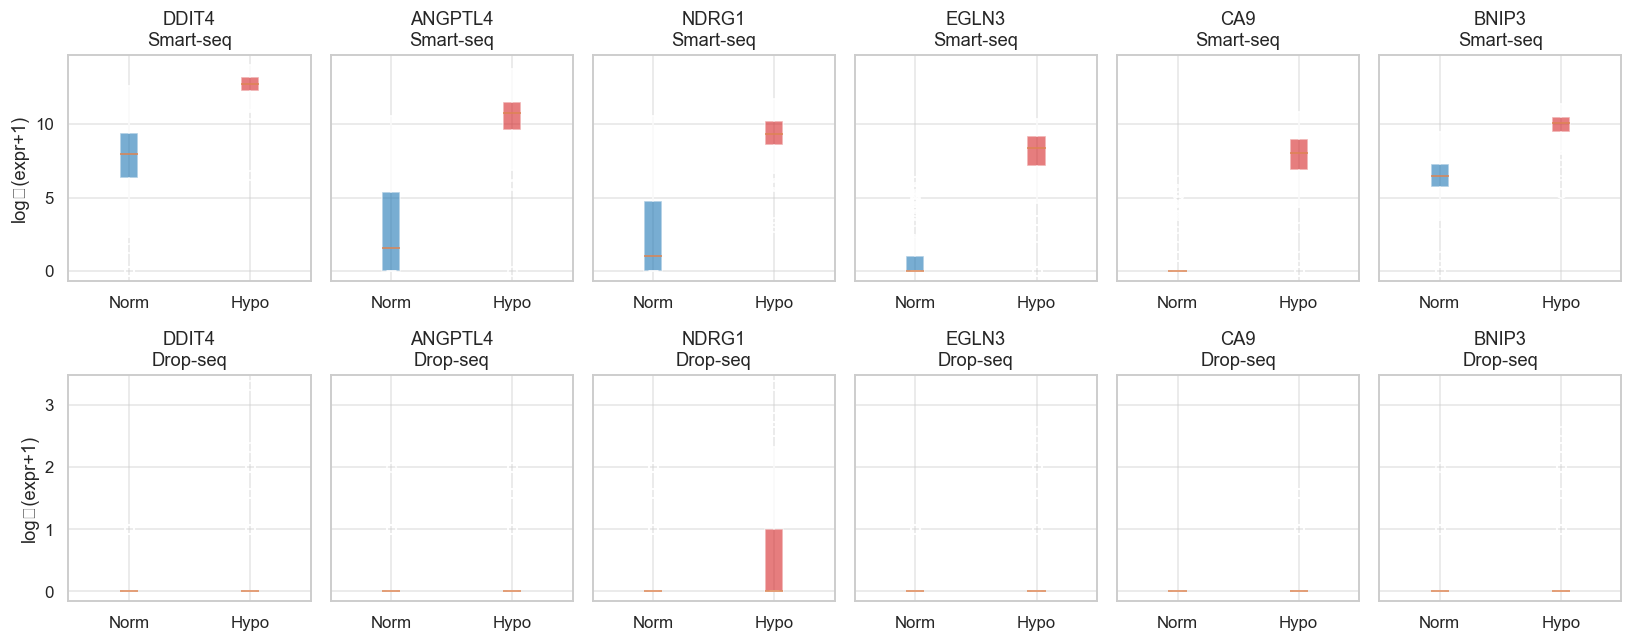

In [18]:
MARKERS = ['DDIT4', 'ANGPTL4', 'NDRG1', 'EGLN3', 'CA9', 'BNIP3']
ss_log_norm = np.log2(ss_norm + 1)
ds_log = np.log2(ds + 1)

fig, axes = plt.subplots(2, len(MARKERS), figsize=(15, 6), sharey='row')
for j, gene in enumerate(MARKERS):
    for i, (name, df) in enumerate([('Smart-seq', ss_log_norm), ('Drop-seq', ds_log)]):
        if gene not in df.index:
            axes[i, j].set_title(f'{gene}\n(not in {name})'); continue
        expr = df.loc[gene]
        c = conditions(df)
        data_by_cond = [expr.values[c == cond] for cond in ['Normoxia', 'Hypoxia']]
        bp = axes[i, j].boxplot(data_by_cond, labels=['Norm', 'Hypo'], patch_artist=True)
        for patch, col in zip(bp['boxes'], [PALETTE['Normoxia'], PALETTE['Hypoxia']]):
            patch.set_facecolor(col); patch.set_alpha(0.6)
        axes[i, j].set_title(f'{gene}\n{name}')
        if j == 0: axes[i, j].set_ylabel('log₂(expr+1)')
plt.tight_layout(); plt.savefig(OUTDIR / 'compare_02_markers.png', dpi=150); plt.show()

**What this tells us:**
- If the boxes are clearly higher in `Hypo` than `Norm` in both rows, the hypoxia response is detectable in both technologies — a strong signal that classifiers should be able to learn.
- The Drop-seq boxes will be at much lower absolute values because of the lower per-cell read counts, but the *direction* of the difference should be the same.
- Genes that show clear separation are good candidates for top features in the supervised model.

## Gene set overlap

In [19]:
ss_genes = set(ss_norm.index)
ds_genes = set(ds.index)
shared = ss_genes & ds_genes
print(f'Smart-seq top-3000 ∩ Drop-seq top-3000 = {len(shared)} genes ({len(shared)/30:.0f}% of each)')
print(f'Hypoxia markers in shared set: {set(MARKERS) & shared}')

Smart-seq top-3000 ∩ Drop-seq top-3000 = 516 genes (17% of each)
Hypoxia markers in shared set: {'CA9', 'ANGPTL4', 'EGLN3', 'BNIP3', 'NDRG1', 'DDIT4'}


**Key takeaway for Phase 3:** the two technologies select different top-variable genes, but the canonical hypoxia genes are present in **both**. This means a cross-technology classifier built on the gene intersection should be able to capture the biological signal even though the rest of the feature space differs.

---
## Summary — Phase 1 findings for the report

1. **Data structure.** Smart-seq HCC1806 = 23,396 genes × 243 cells (filtered to 19,503 × 227, then normalised to 3,000 × 182 for ML); Drop-seq HCC1806 = 3,000 × 14,682. Both are integer matrices with no NaN. Zeros are biological (gene not detected) and treated as data, not missing values.

2. **Condition difference is already visible at the global level.** Mean expression per cell, total signal, and zero fraction are shifted between hypoxia and normoxia in the normalised Smart-seq data, even before any feature-level analysis. This is consistent with hypoxia broadly upregulating many genes via the HIF-1α response.

3. **Distributions are extremely non-normal in raw form** — skewness ≫ 10 and kurtosis in the thousands per cell in raw Smart-seq data. Naive IQR outlier removal destroys the signal because in sparse data the median is 0. The correct preprocessing is **log₂(x+1)** plus library-size normalisation.

4. **Sparsity is large but very different between technologies.** Smart-seq is ~45% zeros; Drop-seq is ~97% zeros. Every downstream decision (feature selection, classifier choice, transfer strategy) has to account for this.

5. **Top-expressed genes are housekeeping/structural** (`MALAT1`, mitochondrial, ribosomal), not informative for classification. The mean-variance plot makes the case for variance-based feature selection.

6. **The 3000-gene normalised files** (which we'll use for ML) have been through QC filtering, library-size normalisation, and variance-based feature selection. We will apply `log₂(x+1)` ourselves before any distance- or variance-based method (PCA, k-means, SVM, logistic regression).

7. **Cross-technology comparison.** The two technologies measure the same biology with very different sampling: Smart-seq is deep but narrow, Drop-seq is shallow but wide. Canonical hypoxia genes (`DDIT4, ANGPTL4, NDRG1, EGLN3, CA9, BNIP3`) are upregulated in hypoxia in **both** technologies, even though only a fraction of each top-3000 gene set is shared. This is the green light for attempting cross-technology classifier transfer in Phase 3.

**Decision for downstream phases:** for both technologies, apply `log₂(x+1)` and standardise features before PCA/clustering/scaling-sensitive classifiers. Use the gene intersection (around 500 genes) for any cross-technology experiment.